In [2]:
import pandas as pd
import numpy as np




df = pd.read_csv('/content/delhi-weather-aqi-2025 (1).csv')
print(df.shape)
df.head()
# ---------- (a) Single attribute: temp_c ----------
temp = df['temp_c']


mean_val = temp.mean()
median_val = temp.median()
mode_val = temp.mode()[0]
range_val = temp.max() - temp.min()
variance_val = temp.var()
std_val = temp.std()
Q1 = temp.quantile(0.25)
Q3 = temp.quantile(0.75)
IQR_val = Q3 - Q1
cov_val = std_val / mean_val
print("Frequency (top 5 values):")
print(temp.value_counts().head())
print(f"Mean               : {mean_val:.2f}")
print(f"Median             : {median_val:.2f}")
print(f"Mode               : {mode_val:.2f}")
print(f"Range              : {range_val:.2f}")
print(f"Variance           : {variance_val:.2f}")
print(f"Standard Deviation : {std_val:.2f}")
print(f"Q1, Q3             : {Q1:.2f}, {Q3:.2f}")
print(f"IQR                : {IQR_val:.2f}")
print(f"Coefficient of Var : {cov_val:.2f}")

(52560, 16)
Frequency (top 5 values):
temp_c
27.5    570
27.0    542
28.0    525
26.5    508
28.5    476
Name: count, dtype: int64
Mean               : 25.02
Median             : 26.50
Mode               : 27.50
Range              : 38.10
Variance           : 58.04
Standard Deviation : 7.62
Q1, Q3             : 19.50, 30.50
IQR                : 11.00
Coefficient of Var : 0.30


In [3]:
sample_df = df[df['location'] == 'Anand Vihar'].head(10)
data = sample_df['temp_c'].tolist()
n = len(data)
print("Sample data:", data)

total = 0
for x in data:
    total = total + x
mean_manual = total / n
print("Manual Mean:", mean_manual)

sorted_data = sorted(data)
if n % 2 == 0:
    median_manual = (sorted_data[n // 2 - 1] + sorted_data[n // 2]) / 2
else:
    median_manual = sorted_data[n // 2]
print("Manual Median:", median_manual)


freq = {}
for x in data:
    freq[x] = freq.get(x, 0) + 1
max_count = max(freq.values())
modes = [value for value, count in freq.items() if count == max_count]
print("Frequency table:", freq)
print("Manual Mode:", modes)


range_manual = max(data) - min(data)

squared_diff_sum = 0
for x in data:
    squared_diff_sum = squared_diff_sum + (x - mean_manual) ** 2
variance_manual = squared_diff_sum / n
std_manual = variance_manual ** 0.5

print("Manual Range:", range_manual)
print("Manual Variance:", variance_manual)
print("Manual Standard Deviation:", std_manual)


def manual_median(lst):
    s = sorted(lst)
    m = len(s)
    if m % 2 == 0:
        return (s[m // 2 - 1] + s[m // 2]) / 2
    return s[m // 2]

lower_half = sorted_data[: n // 2]
upper_half = sorted_data[(n + 1) // 2 :]
Q1_manual = manual_median(lower_half)
Q3_manual = manual_median(upper_half)
IQR_manual = Q3_manual - Q1_manual
print("Manual Q1:", Q1_manual, "| Q3:", Q3_manual, "| IQR:", IQR_manual)


Sample data: [8.1, 7.7, 7.5, 7.8, 7.3, 7.6, 8.1, 8.0, 8.4, 9.4]
Manual Mean: 7.99
Manual Median: 7.9
Frequency table: {8.1: 2, 7.7: 1, 7.5: 1, 7.8: 1, 7.3: 1, 7.6: 1, 8.0: 1, 8.4: 1, 9.4: 1}
Manual Mode: [8.1]
Manual Range: 2.1000000000000005
Manual Variance: 0.3169000000000001
Manual Standard Deviation: 0.562938717801503
Manual Q1: 7.6 | Q3: 8.1 | IQR: 0.5


Frequency of each temperature category:
temp_category
Cold (<15°C)         7226
Mild (15-25°C)      15147
Warm (25-32°C)      21437
Hot (32-38°C)        7183
Heatwave (38°C+)     1567
Name: count, dtype: int64


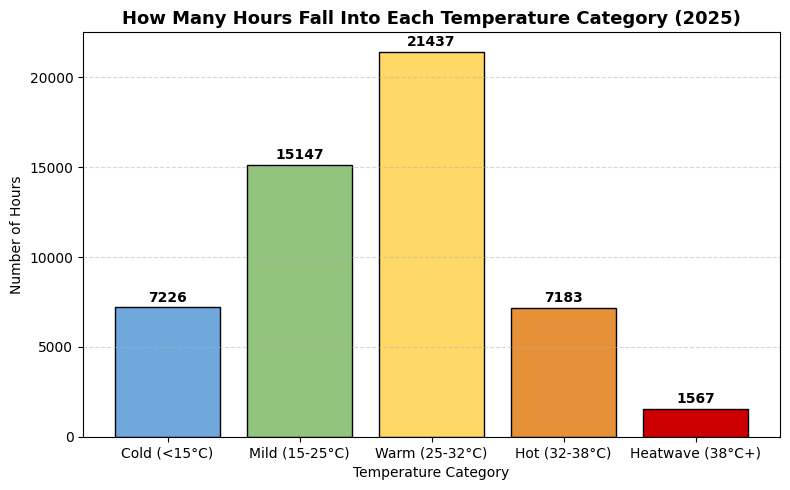


Mean               : 25.02 °C
Median             : 26.50 °C
Mode               : 27.50 °C
Variance           : 58.04
Standard Deviation : 7.62 °C
IQR (Q3 - Q1)      : 11.00 °C

The average temperature (25.02°C) falls in the 'Warm (25-32°C)' category.
The single most common category all year is 'Warm (25-32°C)', with 21437 hours.


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/content/delhi-weather-aqi-2025 (1).csv')

bins   = [0, 15, 25, 32, 38, 50]
labels = ['Cold (<15°C)', 'Mild (15-25°C)', 'Warm (25-32°C)', 'Hot (32-38°C)', 'Heatwave (38°C+)']

df['temp_category'] = pd.cut(df['temp_c'], bins=bins, labels=labels)

# Frequency = how many hours fall into each category
frequency = df['temp_category'].value_counts().sort_index()
print("Frequency of each temperature category:")
print(frequency)

colors = ['#6FA8DC', '#93C47D', '#FFD966', '#E69138', '#CC0000']  # cool blue -> hot red

plt.figure(figsize=(8, 5))
bars = plt.bar(frequency.index.astype(str), frequency.values, color=colors, edgecolor='black')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 300, f'{height}',
              ha='center', fontweight='bold')

plt.title('How Many Hours Fall Into Each Temperature Category (2025)', fontsize=13, fontweight='bold')
plt.xlabel('Temperature Category')
plt.ylabel('Number of Hours')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

mean_val     = df['temp_c'].mean()
median_val   = df['temp_c'].median()
mode_val     = df['temp_c'].mode()[0]
variance_val = df['temp_c'].var()
std_val      = df['temp_c'].std()
Q1           = df['temp_c'].quantile(0.25)
Q3           = df['temp_c'].quantile(0.75)
IQR_val      = Q3 - Q1

print(f"\nMean               : {mean_val:.2f} °C")
print(f"Median             : {median_val:.2f} °C")
print(f"Mode               : {mode_val:.2f} °C")
print(f"Variance           : {variance_val:.2f}")
print(f"Standard Deviation : {std_val:.2f} °C")
print(f"IQR (Q3 - Q1)      : {IQR_val:.2f} °C")

mean_category = pd.cut([mean_val], bins=bins, labels=labels)[0]
most_common_category = frequency.idxmax()

print(f"\nThe average temperature ({mean_val:.2f}°C) falls in the '{mean_category}' category.")
print(f"The single most common category all year is '{most_common_category}', with {frequency.max()} hours.")
